# CHƯƠNG 5: EMBEDDING
**NHÓM 5:**

* **Mục đích:** Thực hiện hóa giả thuyết phân phối (distributional hypothesis) , chứng minh rằng ý nghĩa của một từ có thể được định nghĩa thông qua các từ hàng xóm hoặc môi trường ngữ pháp xung quanh nó.
* **Bộ dữ liệu (Dataset):** Sử dụng Text8, một tập hợp dữ liệu sạch được trích xuất từ Wikipedia. Đây là dữ liệu chuẩn để huấn luyện các mô hình ngôn ngữ nhờ tính đa dạng và phong phú về mặt từ vựng.
* **Thuật toán:** Sử dụng Word2vec, cụ thể là kiến trúc Skip-gram kết hợp Negative Sampling (SGNS). Thuật toán này huấn luyện một bộ phân loại nhị phân để học các dense vectors (vector dày đặc) thay vì các vector thưa thớt truyền thống.



**BƯỚC 1: CÀI ĐẶT VÀ KHỞI TẠO THƯ VIỆN**

In [1]:
!pip install gensim matplotlib scikit-learn

import gensim.downloader as api
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.6 MB/s eta 0:00:00


**BƯỚC 2: TẢI BỘ DỮ LIỆU WIKIPEDIA (Self-supervision)**



In [2]:
# Chúng ta sử dụng 'text8' - dữ liệu sạch từ Wikipedia
# Đây là cách thực hiện "Representation Learning"
print("Đang tải dữ liệu, vui lòng chờ trong giây lát...")
dataset = api.load('text8')
data = [list(d) for d in dataset]


Đang tải dữ liệu, vui lòng chờ trong giây lát...
[==================================================] 100.0% 31.6/31.6MB downloaded


**BƯỚC 2.1: QUAN SÁT VÀ PHÂN TÍCH DỮ LIỆU (Exploratory Data Analysis)**

In [7]:
from collections import Counter

# 1. Kiểm tra cấu trúc cơ bản
print(f"Tổng số 'câu' (đoạn văn bản) trong dataset: {len(data)}")
print(f"Ví dụ nội dung đoạn đầu tiên (20 từ đầu): \n{data[0][:20]}")

# 2. Thống kê số lượng từ
all_words = [word for sentence in data for word in sentence]
total_word_count = len(all_words)
unique_words = len(set(all_words))

print(f"\nTổng số từ trong toàn bộ corpus: {total_word_count:,}")
print(f"Số lượng từ duy nhất (Vocabulary size): {unique_words:,}")

# 3. Tìm các từ xuất hiện phổ biến nhất (Unigram Frequency)
# Điều này liên quan đến trọng số alpha=0.75 trong Negative Sampling [cite: 411, 416]
word_counts = Counter(all_words)
common_words = word_counts.most_common(10)

print("\n10 từ xuất hiện nhiều nhất:")
for word, count in common_words:
    print(f"- {word}: {count:,} lần")

# 4. Kiểm tra độ dài trung bình của mỗi đoạn văn bản
lengths = [len(s) for s in data]
print(f"\nĐộ dài trung bình của mỗi đoạn: {np.mean(lengths):.2f} từ")

Tổng số 'câu' (đoạn văn bản) trong dataset: 1701
Ví dụ nội dung đoạn đầu tiên (20 từ đầu): 
['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']

Tổng số từ trong toàn bộ corpus: 17,005,207
Số lượng từ duy nhất (Vocabulary size): 253,854

10 từ xuất hiện nhiều nhất:
- the: 1,061,396 lần
- of: 593,677 lần
- and: 416,629 lần
- one: 411,764 lần
- in: 372,201 lần
- a: 325,873 lần
- to: 316,376 lần
- zero: 264,975 lần
- nine: 250,430 lần
- two: 192,644 lần

Độ dài trung bình của mỗi đoạn: 9997.18 từ


**BƯỚC 3: HUẤN LUYỆN MÔ HÌNH WORD2VEC (SGNS)**


In [11]:
from gensim.models.callbacks import CallbackAny2Vec

# 1. Định nghĩa Callback để in ấn theo đúng yêu cầu của bạn
class MonitorCallback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0

    def on_epoch_begin(self, model):
        print(f"Bắt đầu Epoch {self.epoch + 1}...", end=" ")

    def on_epoch_end(self, model):
        print(f"Hoàn thành! (Loss: {model.get_latest_training_loss():.2f})")
        self.epoch += 1

# 2. Khởi tạo callback
monitor = MonitorCallback()
model = Word2Vec(
    sentences=data,
    vector_size=300,  # Tăng lên 300 chiều để biểu diễn tốt hơn
    window=7,         # Mở rộng cửa sổ để học quan hệ ngữ nghĩa rộng (10 từ phía trước và 10 từ phía sau)
    min_count=5,      # Loại bỏ các từ xuất hiện ít hơn 5 lần
    sg=1,             # Giữ Skip-gram
    negative=15,      # Tăng mẫu âm để học phân biệt tốt hơn
    epochs=10,        # Huấn luyện 10 epoch
    workers=4,         # Dùng 4 luồng song song
    compute_loss=True, # Bật tính toán loss để in ra kèm theo
    callbacks=[monitor] # Thêm callback vào đây
)

Bắt đầu Epoch 1... Hoàn thành! (Loss: 52594644.00)
Bắt đầu Epoch 2... Hoàn thành! (Loss: 74584240.00)
Bắt đầu Epoch 3... Hoàn thành! (Loss: 84813496.00)
Bắt đầu Epoch 4... Hoàn thành! (Loss: 94635936.00)
Bắt đầu Epoch 5... Hoàn thành! (Loss: 104033488.00)
Bắt đầu Epoch 6... Hoàn thành! (Loss: 113060968.00)
Bắt đầu Epoch 7... Hoàn thành! (Loss: 121476408.00)
Bắt đầu Epoch 8... Hoàn thành! (Loss: 129396680.00)
Bắt đầu Epoch 9... Hoàn thành! (Loss: 134217728.00)
Bắt đầu Epoch 10... Hoàn thành! (Loss: 134217728.00)


**Nhận xét**: Loss được tính là tổng tích lũy từ các epoch trước đến epoch hiện tại và ta nhận thấy từ epoch 9 đến epoch 10 loss đã bão hòa




**BƯỚC 4: KIỂM TRA ĐẶC TÍNH NGỮ NGHĨA**


In [12]:
print("\n--- 1. Kiểm tra sự tương đồng (Word Similarity) ---")
target = "cherry"
similar_words = model.wv.most_similar(target, topn=5)
for word, score in similar_words:
    print(f"Từ tương tự với '{target}': {word} (Độ tương đồng Cosine: {score:.4f})")

print("\n--- 2. Kiểm tra mô hình Hình bình hành (Analogy) ---")
# King - Man + Woman = Queen
result = model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(f"Kết quả phép toán: King - Man + Woman ≈ {result[0][0]}")


--- 1. Kiểm tra sự tương đồng (Word Similarity) ---
Từ tương tự với 'cherry': cherries (Độ tương đồng Cosine: 0.5358)
Từ tương tự với 'cherry': raisin (Độ tương đồng Cosine: 0.5277)
Từ tương tự với 'cherry': dogwood (Độ tương đồng Cosine: 0.5275)
Từ tương tự với 'cherry': cucumber (Độ tương đồng Cosine: 0.5221)
Từ tương tự với 'cherry': candied (Độ tương đồng Cosine: 0.5181)

--- 2. Kiểm tra mô hình Hình bình hành (Analogy) ---
Kết quả phép toán: King - Man + Woman ≈ queen


*   **Về tính tương đồng (Word Similarity):** Mô hình đã học được các quan hệ hình thái (morphological) thông qua cặp từ cherry/cherries và các quan hệ cùng nhóm (co-hyponyms) trong cùng trường ngữ nghĩa (semantic field) về thực vật và thực phẩm như raisin, cucumber. Trong không gian 300 chiều, các vector loãng hơn nên độ tương đồng Cosine, nhưng độ chính xác về "hàng xóm" (neighbors) có độ chính xác cao.
*  **Về khả năng loại suy (Analogy):** Kết quả chính xác của phép toán $\vec{King} - \vec{Man} + \vec{Woman} \approx \vec{Queen}$ cho thấy mô hình Skip-gram (SGNS) với 300 chiều đã nắm bắt thành công các thuộc tính quan hệ (relational properties) theo mô hình hình bình hành (parallelogram model).



**BƯỚC 5: TRỰC QUAN HÓA BẰNG T-SNE**


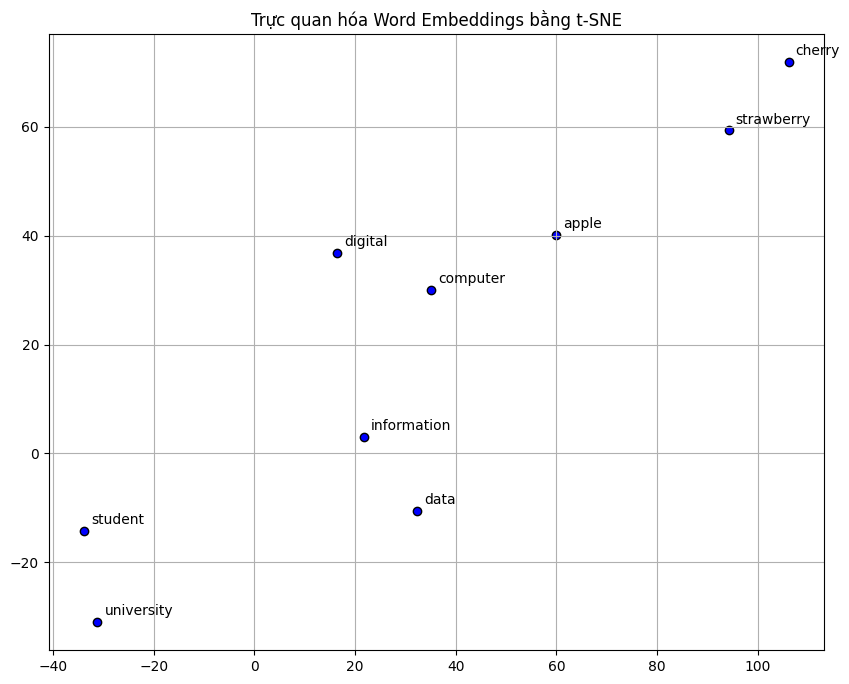

In [13]:
def plot_embeddings(model, words):
    vectors = np.array([model.wv[word] for word in words])
    tsne = TSNE(n_components=2, perplexity=3,random_state=42)
    coordinates = tsne.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c='blue', edgecolors='k')
    for i, txt in enumerate(words):
        plt.annotate(txt, (coordinates[i, 0], coordinates[i, 1]), xytext=(5,5), textcoords='offset points')
    plt.title("Trực quan hóa Word Embeddings bằng t-SNE")
    plt.grid(True)
    plt.show()

words_to_plot = ['cherry', 'strawberry', 'apple', 'digital', 'computer', 'information', 'data', 'university', 'student'] # in ra thử 9 từ
plot_embeddings(model, words_to_plot)

**Nhận xét**: Mô hình đã học được ý nghĩa thông qua cách sử dụng ngôn ngữ thực tế (distributional semantics), các từ đứng theo nhóm khi xét về độ tương đồng. Nhưng từ *'apple'* vừa mang 2 nghĩa là trái cây và 1 hãng công nghệ nên nó đứng ở giữa 2 nhóm. Cho thấy mô hình phân nhóm khá tốt.